<a href="https://colab.research.google.com/github/pradnyapagale7654/AI-Powered-Study-Planner/blob/main/Seasonal_Agriculture_Performance_Analysis_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Seasonal Agriculture Performance Analysis

**Major Project: Seasonal Agriculture Performance Analysis**

### Project objective
Analyze agricultural data across different seasons to identify:
- seasonal patterns and trends
- differences in agricultural performance
- environmental and resource-use relationships
- economic performance
- unusual observations
- evidence-based recommendations

This notebook follows the project requirements and is designed to run directly in **Google Colab**.


In [1]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Upload and Load Dataset

If the CSV is already present in Colab, change `file_path` to its location.

Otherwise, run the upload code below and select the agriculture CSV file from your computer.


In [2]:
# ============================================
# 2. UPLOAD DATASET
# ============================================

from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File:", file_name)
print("Shape:", df.shape)
display(df.head())


Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv
Dataset loaded successfully!
File: seasonal_agriculture_performance_dataset (1).csv
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,7.140,32.800,75.800,61.300,91.000,Drip,242.700,4.330,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,5.200,32.000,82.100,35.400,121.800,Flood,271.400,6.860,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,5.820,8.100,118.500,51.500,117.900,Drip,162.600,6.080,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700
3,SF10004,Telangana,Indore,Rice,Kharif,4.500,753.200,29.700,65.200,6.300,5.980,23.700,138.600,55.600,115.500,Rainfed,182.200,6.390,0.740,1.840,8.280,24244,296444,200740,-95704,3834,2.160,50.600
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.210,101.600,34.100,55.200,6.500,6.900,29.300,124.100,69.000,121.400,Flood,244.900,7.610,0.900,2.210,9.300,20818,337959,193607,-144352,3287,2.829,32.300


In [3]:
# ============================================
# 3. BASIC DATASET INFORMATION
# ============================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset information:")
df.info()


Number of rows: 4000
Number of columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha            

In [4]:
# ============================================
# 4. DESCRIPTIVE STATISTICS
# ============================================

print("Numerical summary:")
display(df.describe(include="all").T)


Numerical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.000",NaN,NaN,NaN,7.888,4.224,0.500,4.260,7.895,11.650,15.000
Rainfall_mm,"3,952.000",NaN,NaN,NaN,601.153,288.925,80.000,370.200,582.000,834.950,"1,395.200"
Avg_Temperature_C,"4,000.000",NaN,NaN,NaN,26.819,3.818,16.200,23.900,26.900,29.600,39.700
Humidity_pct,"4,000.000",NaN,NaN,NaN,63.211,11.961,25.000,54.775,63.000,71.900,95.000
Sunlight_Hours_Day,"4,000.000",NaN,NaN,NaN,7.323,1.121,3.500,6.600,7.300,8.100,11.000


## 3. Data Quality Check

We check:
1. Missing values
2. Duplicate records
3. Invalid/negative values in important numerical columns
4. Unique categories


In [5]:
# ============================================
# 5. MISSING VALUES
# ============================================

missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_pct
})

display(missing_table[missing_table["Missing Values"] > 0])

if missing.sum() == 0:
    print("No missing values found.")


,Missing Values,Missing Percentage
Rainfall_mm,48,1.200
Soil_Moisture_pct,40,1.000
Yield_Tonnes_Ha,32,0.800


In [6]:
# ============================================
# 6. DUPLICATE RECORDS
# ============================================

duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
    print("New shape:", df.shape)
else:
    print("No duplicate rows found.")


Duplicate rows: 0
No duplicate rows found.


In [7]:
# ============================================
# 7. UNIQUE VALUES IN CATEGORICAL COLUMNS
# ============================================

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(20))



Farm_ID:
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
SF13979    1
SF13978    1
SF13977    1
SF13976    1
SF13975    1
SF13974    1
SF13973    1
SF13972    1
SF13971    1
SF13970    1
SF13969    1
SF10032    1
SF10031    1
SF10030    1
SF10029    1
Name: count, dtype: int64

State:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District:
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_M

In [8]:
# ============================================
# 8. NUMERICAL DATA QUALITY CHECK
# ============================================

numeric_cols = df.select_dtypes(include=np.number).columns

negative_counts = (df[numeric_cols] < 0).sum().sort_values(ascending=False)
print("Negative values by numerical column:")
display(negative_counts[negative_counts > 0])

# Variables that logically should not be negative
non_negative_cols = [
    "Farm_Area_Hectares", "Rainfall_mm", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Yield_Tonnes_Ha", "Production_Tonnes",
    "Market_Price_INR_Tonne", "Total_Cost_INR", "Revenue_INR",
    "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

for col in non_negative_cols:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

print("Logical negative-value check completed.")


Negative values by numerical column:


,0
Profit_INR,1966


Logical negative-value check completed.


## 4. Missing-Value Treatment

Numerical columns are filled with their median.  
Categorical columns are filled with their mode.

Median is used for numerical variables because it is less affected by extreme observations.


In [9]:
# ============================================
# 9. HANDLE MISSING VALUES
# ============================================

for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include="object").columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing-value treatment completed.")
print("Remaining missing values:", df.isnull().sum().sum())


Missing-value treatment completed.
Remaining missing values: 0


## 5. Exploratory Data Analysis

The following questions are investigated:

- How does performance vary across seasons?
- Which crops/seasons have higher yield?
- How do environmental conditions change?
- How does resource usage vary?
- How does profit differ?
- How does irrigation method relate to water efficiency?
- Are there relationships between environmental variables and yield?


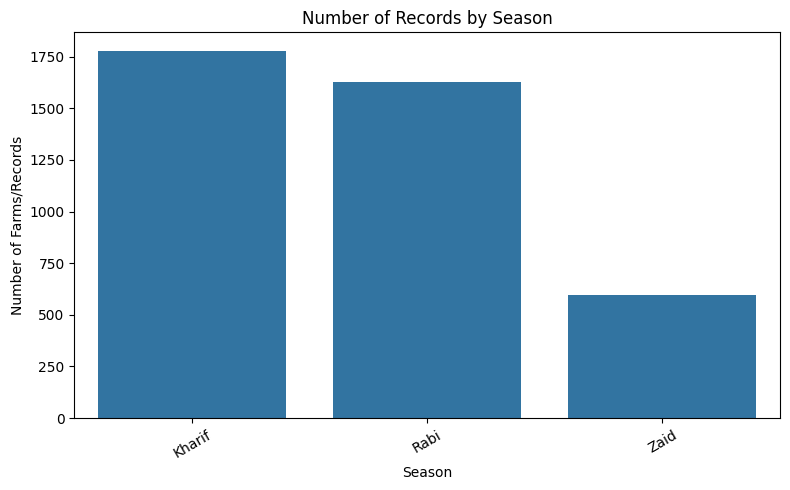

In [10]:
# ============================================
# 10. SEASON DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Season", order=df["Season"].value_counts().index)
plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms/Records")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


,Average Yield (Tonnes/Ha)
Season,
Kharif,5.629
Rabi,5.039
Zaid,4.641


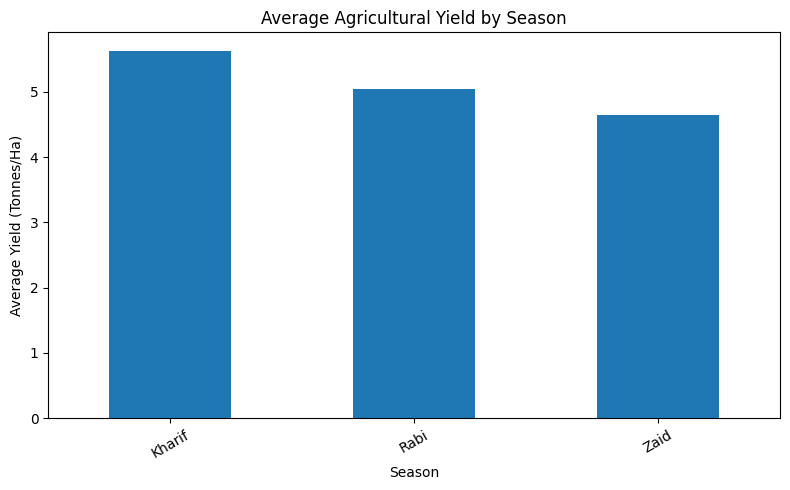

In [11]:
# ============================================
# 11. AVERAGE YIELD BY SEASON
# ============================================

season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

display(season_yield.to_frame("Average Yield (Tonnes/Ha)"))

plt.figure(figsize=(8, 5))
season_yield.plot(kind="bar")
plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


,Average Profit (INR)
Season,
Kharif,"178,914.648"
Rabi,"87,689.470"
Zaid,"-24,804.825"


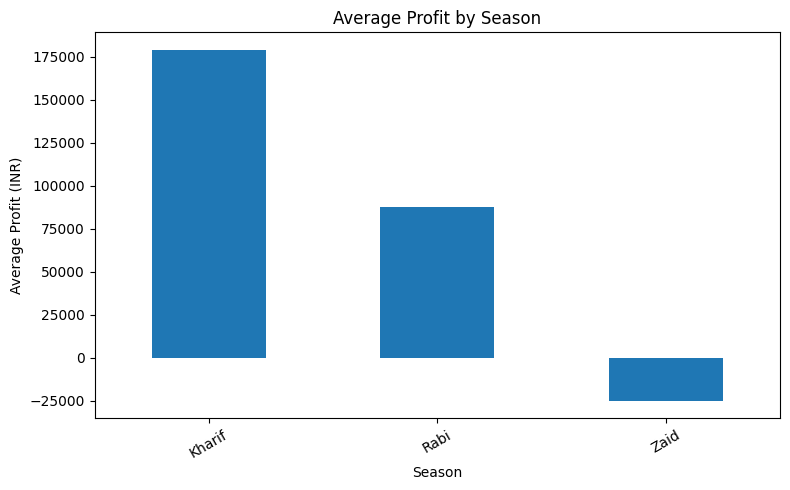

In [12]:
# ============================================
# 12. AVERAGE PROFIT BY SEASON
# ============================================

season_profit = df.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)

display(season_profit.to_frame("Average Profit (INR)"))

plt.figure(figsize=(8, 5))
season_profit.plot(kind="bar")
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Zaid,"6,419.894",4.413
Kharif,"6,102.201",5.892
Rabi,"5,846.987",5.186


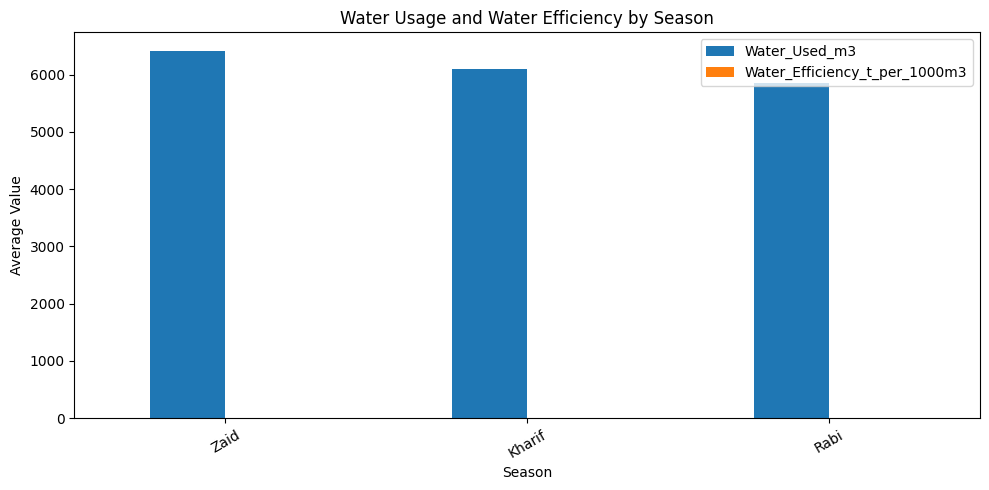

In [13]:
# ============================================
# 13. WATER USAGE AND WATER EFFICIENCY BY SEASON
# ============================================

water_summary = df.groupby("Season")[[
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]].mean().sort_values("Water_Used_m3", ascending=False)

display(water_summary)

water_summary.plot(kind="bar", figsize=(10, 5))
plt.title("Water Usage and Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.200,28.454,71.813,6.793,31.150
Rabi,437.615,23.489,57.893,7.590,24.069
Zaid,304.655,31.042,52.012,8.179,19.280


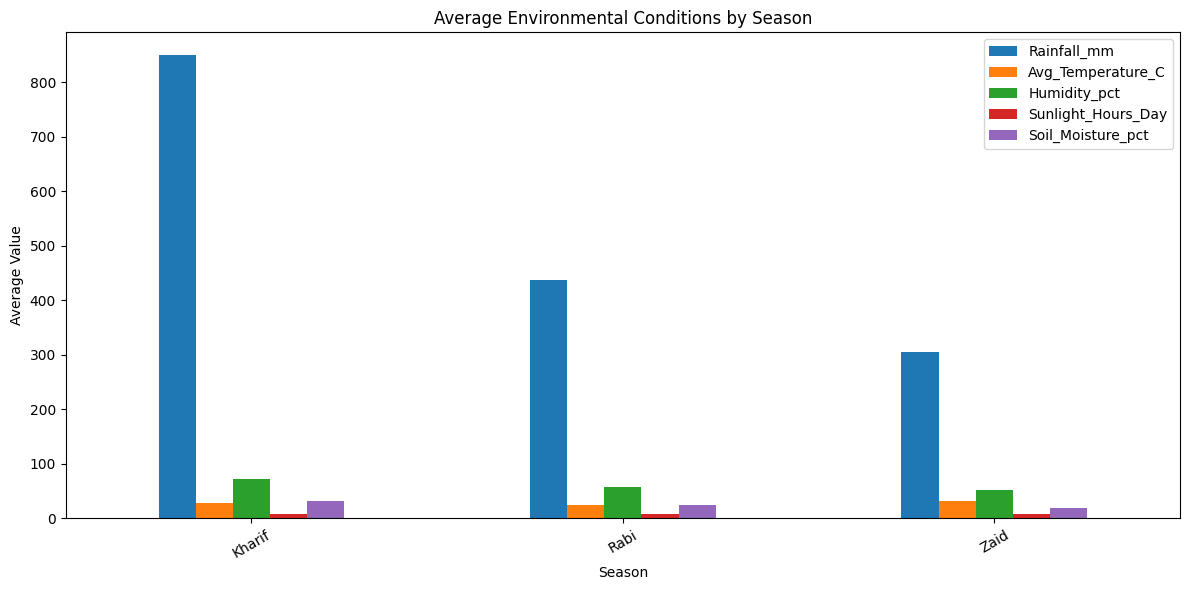

In [14]:
# ============================================
# 14. ENVIRONMENTAL CONDITIONS BY SEASON
# ============================================

environment_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct"
]

environment_summary = df.groupby("Season")[environment_cols].mean()
display(environment_summary)

environment_summary.plot(kind="bar", figsize=(12, 6))
plt.title("Average Environmental Conditions by Season")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


,Average_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Records
Crop,,,,,
Sugarcane,46.642,"817,187.987","13,897.705",30.478,305
Maize,2.710,"-83,978.327","4,377.777",5.603,551
Rice,2.431,"-102,213.504","10,920.216",1.946,690
Wheat,2.108,"-123,398.337","4,054.402",4.628,614
Chilli,1.543,"750,878.342","4,577.468",2.948,412
Groundnut,1.323,"44,858.120","3,459.535",3.155,424
Cotton,1.230,"124,546.915","5,410.858",1.938,508
Pulses,0.922,"-4,238.052","2,833.665",2.897,496


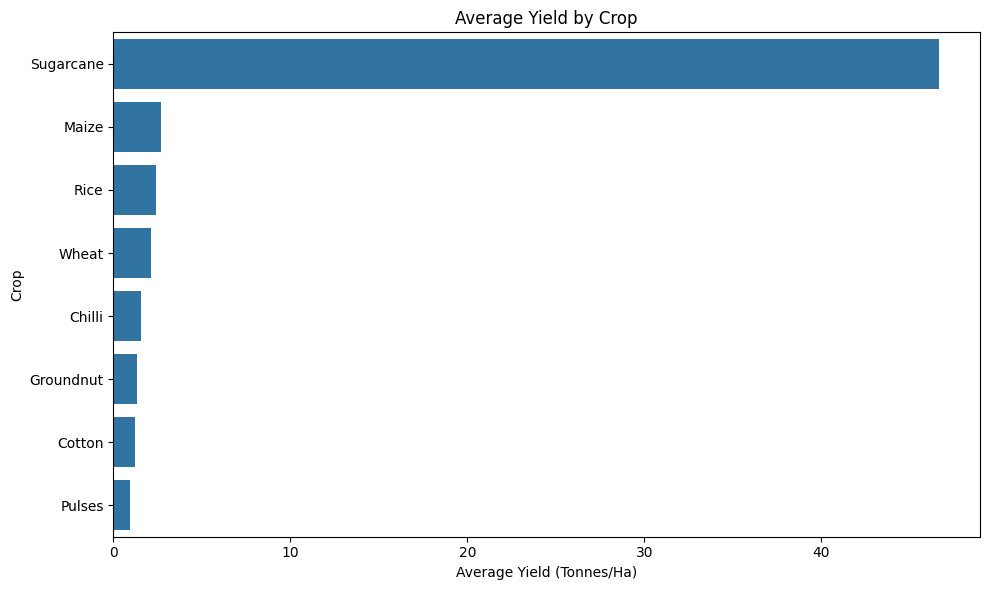

In [15]:
# ============================================
# 15. CROP PERFORMANCE
# ============================================

crop_summary = df.groupby("Crop").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Records=("Crop", "size")
).sort_values("Average_Yield", ascending=False)

display(crop_summary)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=crop_summary.reset_index(),
    x="Average_Yield",
    y="Crop"
)
plt.title("Average Yield by Crop")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()


,Average_Yield,Average_Water_Used,Average_Water_Efficiency,Average_Profit,Records
Irrigation_Method,,,,,
Rainfed,4.602,"3,549.554",7.564,"79,050.365",1041
Drip,6.578,"5,918.748",6.267,"219,625.998",915
Sprinkler,5.161,"6,208.259",4.670,"91,121.079",734
Flood,4.864,"8,026.473",3.439,"73,354.023",1310


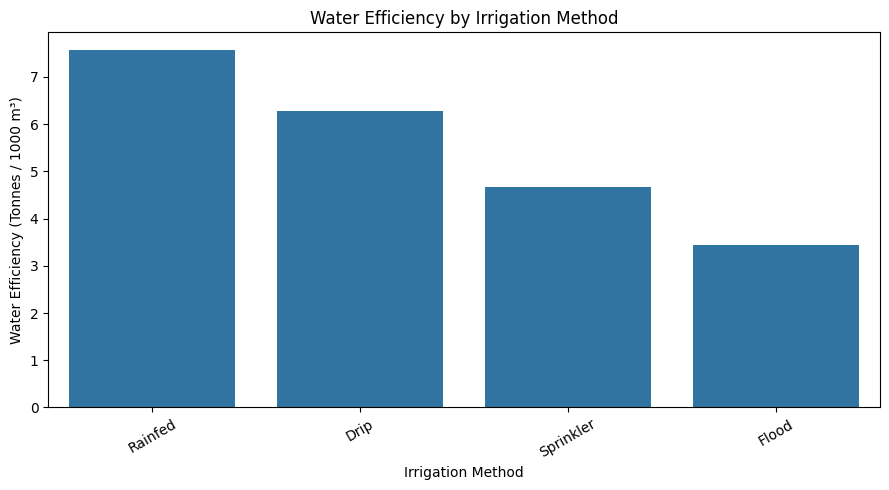

In [16]:
# ============================================
# 16. IRRIGATION METHOD ANALYSIS
# ============================================

irrigation_summary = df.groupby("Irrigation_Method").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Records=("Irrigation_Method", "size")
).sort_values("Average_Water_Efficiency", ascending=False)

display(irrigation_summary)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=irrigation_summary.reset_index(),
    x="Irrigation_Method",
    y="Average_Water_Efficiency"
)
plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes / 1000 m³)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,,,
Kharif,120.020,58.097,105.303,187.078,5.080
Rabi,120.403,57.311,103.926,185.407,5.025
Zaid,120.525,58.129,105.417,184.638,5.171


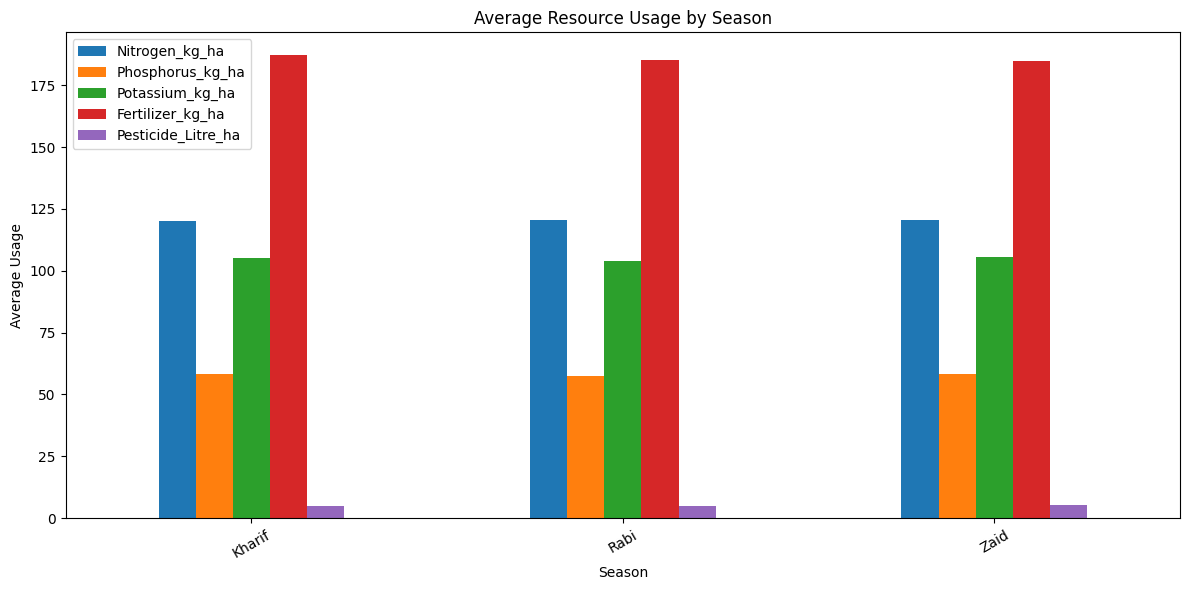

In [17]:
# ============================================
# 17. RESOURCE USAGE BY SEASON
# ============================================

resource_cols = [
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha"
]

resource_summary = df.groupby("Season")[resource_cols].mean()
display(resource_summary)

resource_summary.plot(kind="bar", figsize=(12, 6))
plt.title("Average Resource Usage by Season")
plt.xlabel("Season")
plt.ylabel("Average Usage")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,"44,850.906","531,804.408","710,719.056","178,914.648"
Rabi,"44,747.975","513,836.578","601,526.049","87,689.470"
Zaid,"44,212.034","543,976.729","519,171.904","-24,804.825"


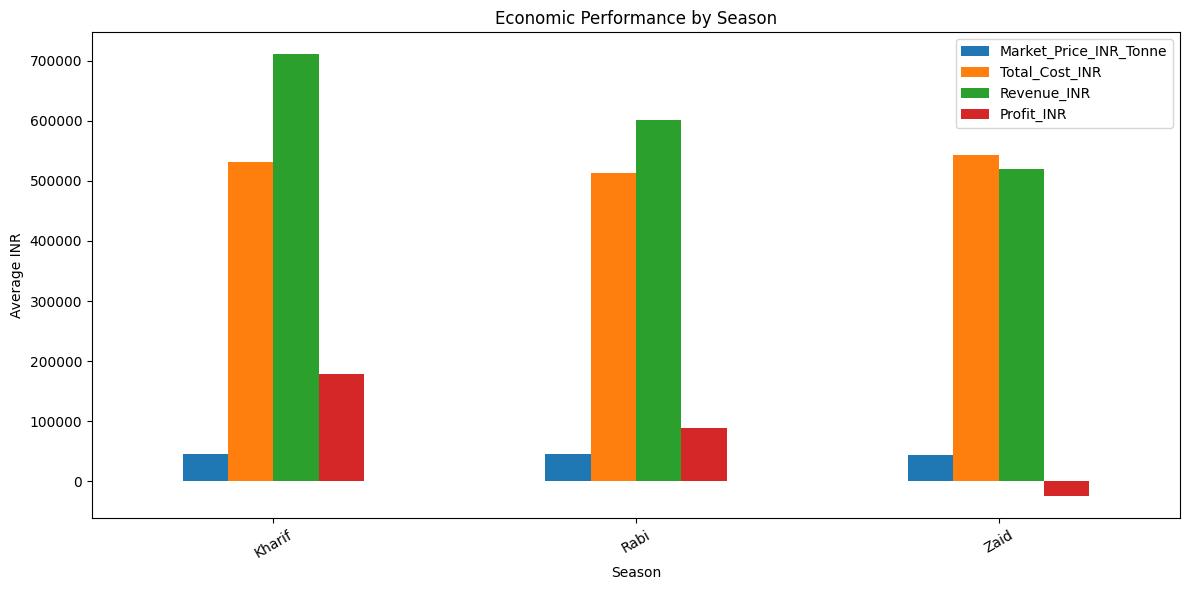

In [18]:
# ============================================
# 18. ECONOMIC PERFORMANCE
# ============================================

economic_cols = [
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR"
]

economic_summary = df.groupby("Season")[economic_cols].mean()
display(economic_summary)

economic_summary.plot(kind="bar", figsize=(12, 6))
plt.title("Economic Performance by Season")
plt.xlabel("Season")
plt.ylabel("Average INR")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731,1.465,1.195
Cotton,1.375,1.198,0.960
Groundnut,1.485,1.233,1.038
Maize,2.966,2.604,2.291
Pulses,1.036,0.876,0.670
Rice,2.698,2.323,1.900
Sugarcane,53.459,43.286,38.424
Wheat,2.254,2.057,1.749


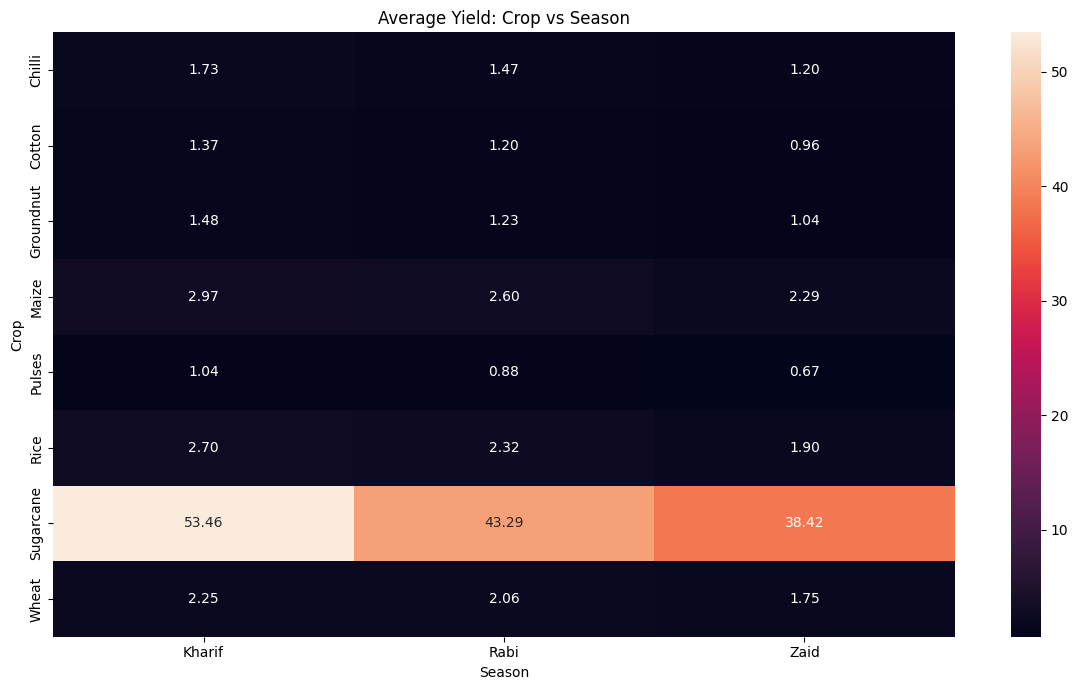

In [19]:
# ============================================
# 19. SEASON × CROP COMPARISON
# ============================================

season_crop = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

display(season_crop)

plt.figure(figsize=(12, 7))
sns.heatmap(season_crop, annot=True, fmt=".2f")
plt.title("Average Yield: Crop vs Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()


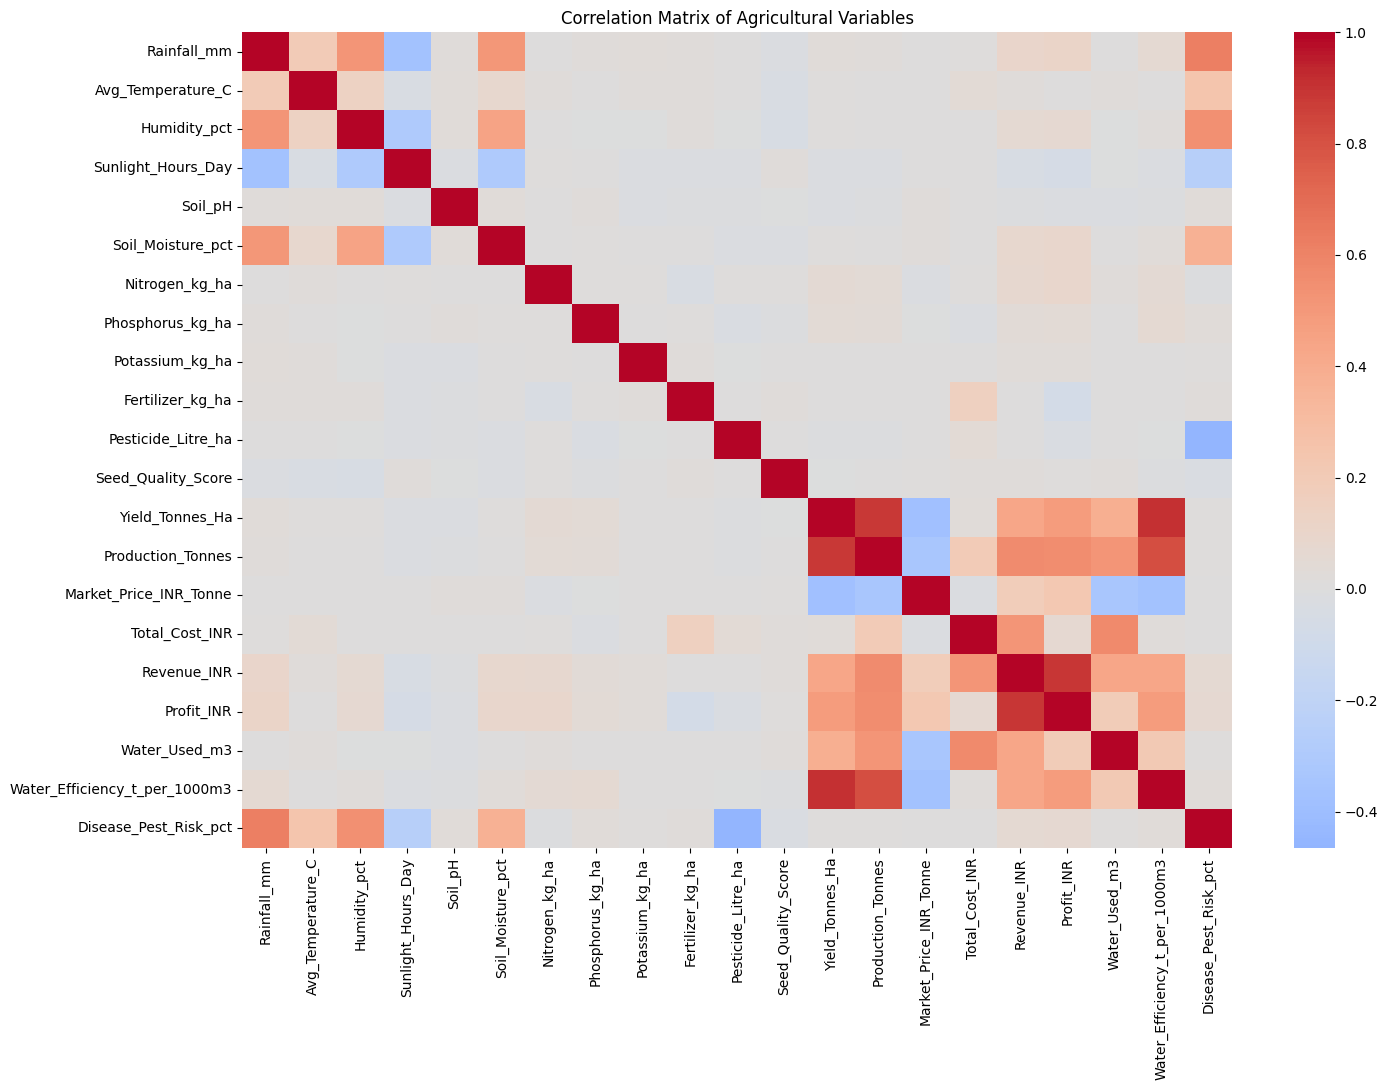

Variables most correlated with Yield:


,Correlation with Yield
Yield_Tonnes_Ha,1.000
Water_Efficiency_t_per_1000m3,0.913
Production_Tonnes,0.883
Profit_INR,0.488
Revenue_INR,0.432
Water_Used_m3,0.386
Nitrogen_kg_ha,0.053
Phosphorus_kg_ha,0.048
Rainfall_mm,0.031
Total_Cost_INR,0.031


In [20]:
# ============================================
# 20. CORRELATION ANALYSIS
# ============================================

corr_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_pH", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Yield_Tonnes_Ha",
    "Production_Tonnes", "Market_Price_INR_Tonne",
    "Total_Cost_INR", "Revenue_INR", "Profit_INR",
    "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr()

plt.figure(figsize=(15, 11))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Agricultural Variables")
plt.tight_layout()
plt.show()

print("Variables most correlated with Yield:")
display(
    corr["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
    .to_frame("Correlation with Yield")
)


In [21]:
# ============================================
# 21. OUTLIER DETECTION USING IQR
# ============================================

outlier_results = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_results.append({
        "Column": col,
        "Outlier_Count": count,
        "Outlier_Percentage": (count / len(df)) * 100
    })

outlier_table = pd.DataFrame(outlier_results).sort_values(
    "Outlier_Count", ascending=False
)

display(outlier_table.head(15))


,Column,Outlier_Count,Outlier_Percentage
18,Profit_INR,404,10.100
14,Production_Tonnes,333,8.325
20,Water_Efficiency_t_per_1000m3,322,8.050
13,Yield_Tonnes_Ha,302,7.550
19,Water_Used_m3,276,6.900
17,Revenue_INR,240,6.000
9,Potassium_kg_ha,32,0.800
4,Sunlight_Hours_Day,26,0.650
8,Phosphorus_kg_ha,16,0.400
10,Fertilizer_kg_ha,15,0.375


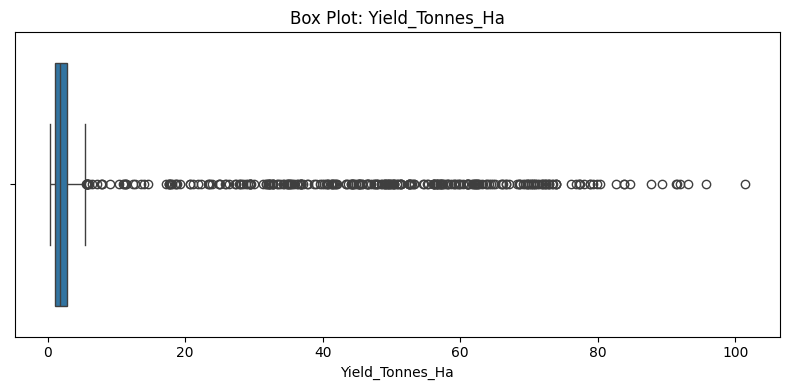

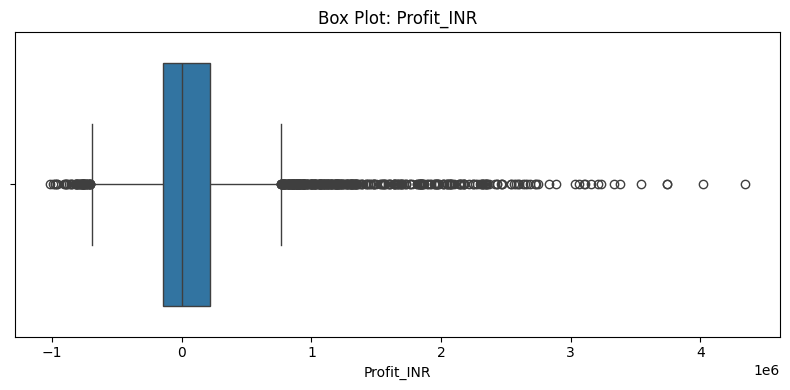

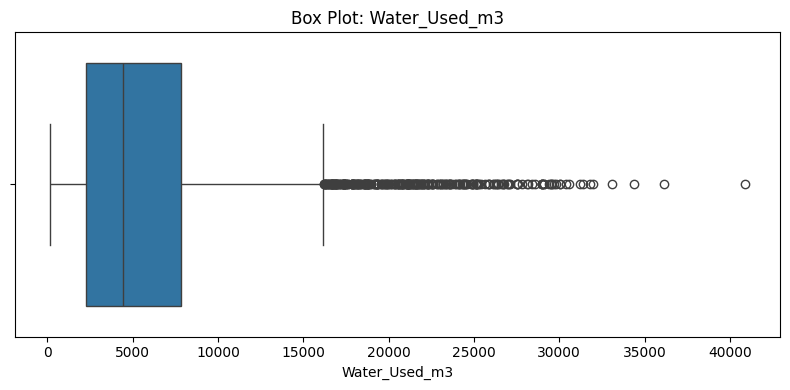

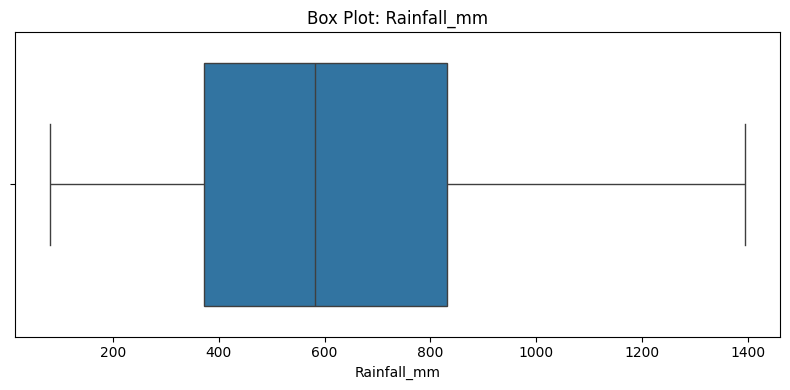

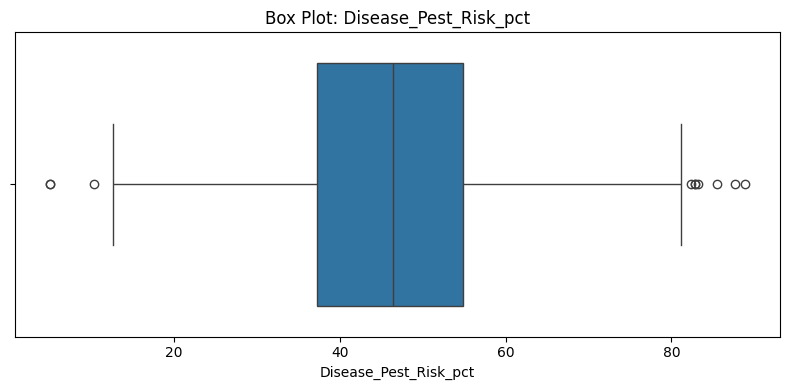

In [22]:
# ============================================
# 22. BOX PLOTS FOR IMPORTANT VARIABLES
# ============================================

important_box_cols = [
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Used_m3",
    "Rainfall_mm",
    "Disease_Pest_Risk_pct"
]

for col in important_box_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Box Plot: {col}")
        plt.tight_layout()
        plt.show()


## 6. Statistical Comparison Across Seasons

ANOVA is used as a statistical test to check whether the mean of an important agricultural performance variable differs across seasons.

**Interpretation rule:**
- p-value < 0.05 → statistically significant difference
- p-value ≥ 0.05 → no statistically significant difference detected


In [23]:
# ============================================
# 23. ONE-WAY ANOVA
# ============================================

from scipy.stats import f_oneway

def anova_by_season(data, value_col):
    groups = [
        group[value_col].dropna().values
        for _, group in data.groupby("Season")
    ]
    groups = [g for g in groups if len(g) > 1]

    if len(groups) >= 2:
        statistic, p_value = f_oneway(*groups)
        return statistic, p_value
    return np.nan, np.nan

anova_variables = [
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]

anova_results = []

for col in anova_variables:
    if col in df.columns:
        stat, p = anova_by_season(df, col)
        anova_results.append({
            "Variable": col,
            "F_Statistic": stat,
            "P_Value": p,
            "Significant_at_0.05": "Yes" if p < 0.05 else "No"
        })

anova_table = pd.DataFrame(anova_results)
display(anova_table)


,Variable,F_Statistic,P_Value,Significant_at_0.05
0,Yield_Tonnes_Ha,1.544,0.214,No
1,Profit_INR,34.292,0.000,Yes
2,Water_Used_m3,2.467,0.085,No
3,Water_Efficiency_t_per_1000m3,6.948,0.001,Yes


## 7. Optional Machine Learning: Yield Prediction

A Random Forest Regressor is used as an additional analytical model to estimate **Yield_Tonnes_Ha** from available environmental, resource, farm and categorical characteristics.

This section is optional if the project is intended to remain purely descriptive.


In [24]:
# ============================================
# 24. PREPARE DATA FOR MACHINE LEARNING
# ============================================

ml_df = df.copy()

# Drop identifier columns
drop_cols = [c for c in ["Farm_ID"] if c in ml_df.columns]
ml_df = ml_df.drop(columns=drop_cols)

# One-hot encode categorical variables
categorical_ml = ml_df.select_dtypes(include="object").columns
ml_df = pd.get_dummies(ml_df, columns=categorical_ml, drop_first=True)

target = "Yield_Tonnes_Ha"

X = ml_df.drop(columns=[target])
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Random Forest Yield Prediction Results")
print("--------------------------------------")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")


Random Forest Yield Prediction Results
--------------------------------------
MAE  : 0.497
RMSE : 1.737
R²   : 0.984


,Importance
Water_Efficiency_t_per_1000m3,0.900
Profit_INR,0.027
Production_Tonnes,0.021
Irrigation_Method_Rainfed,0.008
Soil_pH,0.007
Farm_Area_Hectares,0.006
Market_Price_INR_Tonne,0.006
Rainfall_mm,0.003
Total_Cost_INR,0.002
Potassium_kg_ha,0.002


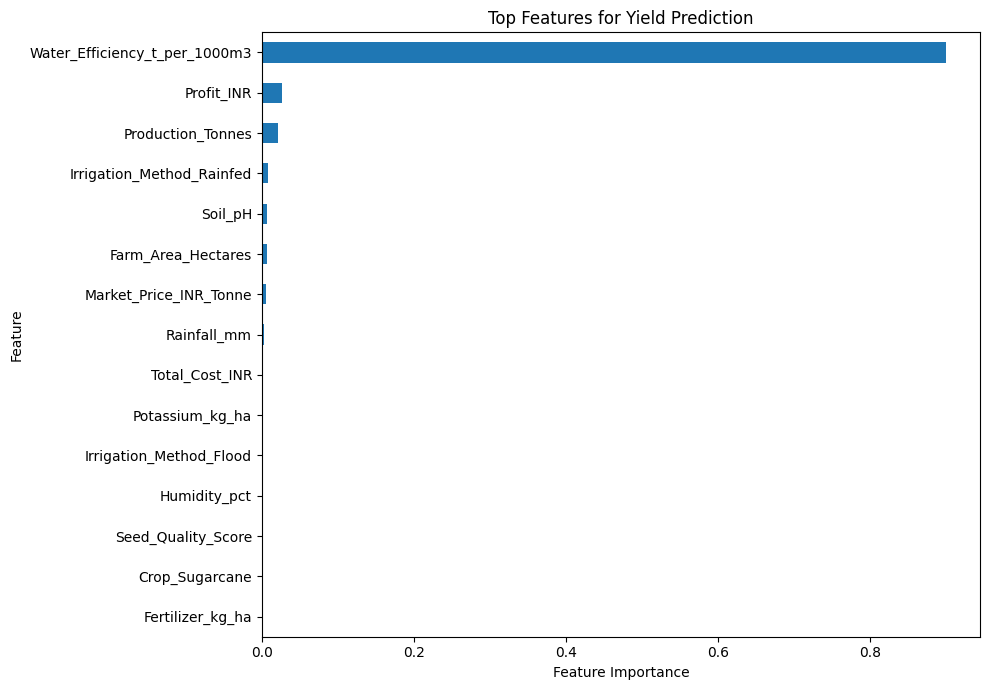

In [25]:
# ============================================
# 25. FEATURE IMPORTANCE
# ============================================

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(importance.head(15).to_frame("Importance"))

plt.figure(figsize=(10, 7))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top Features for Yield Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 8. Automatically Generate Key Findings

The following cell summarizes the strongest season-wise differences found in the dataset.


In [26]:
# ============================================
# 26. KEY FINDINGS
# ============================================

best_yield_season = season_yield.idxmax()
best_yield_value = season_yield.max()

best_profit_season = season_profit.idxmax()
best_profit_value = season_profit.max()

best_water_eff_season = (
    df.groupby("Season")["Water_Efficiency_t_per_1000m3"]
    .mean()
    .idxmax()
)

highest_water_season = (
    df.groupby("Season")["Water_Used_m3"]
    .mean()
    .idxmax()
)

print("KEY FINDINGS")
print("============")
print(f"1. Highest average yield: {best_yield_season} ({best_yield_value:.2f} tonnes/ha)")
print(f"2. Highest average profit: {best_profit_season} (INR {best_profit_value:,.2f})")
print(f"3. Highest average water efficiency: {best_water_eff_season}")
print(f"4. Highest average water usage: {highest_water_season}")

if "Crop" in df.columns:
    best_crop = crop_summary["Average_Yield"].idxmax()
    print(f"5. Highest average-yield crop: {best_crop}")

if "Irrigation_Method" in df.columns:
    best_irrigation = irrigation_summary["Average_Water_Efficiency"].idxmax()
    print(f"6. Most water-efficient irrigation method in this dataset: {best_irrigation}")


KEY FINDINGS
1. Highest average yield: Kharif (5.63 tonnes/ha)
2. Highest average profit: Kharif (INR 178,914.65)
3. Highest average water efficiency: Kharif
4. Highest average water usage: Zaid
5. Highest average-yield crop: Sugarcane
6. Most water-efficient irrigation method in this dataset: Rainfed


## 9. Data-Driven Recommendations

Recommendations should be based on the actual patterns observed above.

Typical evidence-based recommendations can include:

1. Prefer seasonal planning based on the season with stronger observed yield/profit.
2. Promote irrigation methods associated with higher observed water efficiency.
3. Monitor seasons with high water consumption and investigate opportunities for efficient irrigation.
4. Adjust fertilizer, pesticide and nutrient management according to crop and seasonal conditions.
5. Monitor environmental conditions such as rainfall, temperature and soil moisture when planning crop activities.
6. Investigate unusually high disease/pest-risk observations.
7. Use the strongest yield-related variables identified by correlation and feature importance for future predictive systems.

**Important:** These are recommendations to investigate based on the dataset; they should not be treated as universal agricultural rules.


In [27]:
# ============================================
# 27. SAVE CLEANED DATASET
# ============================================

cleaned_file = "seasonal_agriculture_performance_cleaned.csv"
df.to_csv(cleaned_file, index=False)

print("Cleaned dataset saved as:", cleaned_file)

# Uncomment the next two lines in Google Colab to download it:
# from google.colab import files
# files.download(cleaned_file)


Cleaned dataset saved as: seasonal_agriculture_performance_cleaned.csv


# ✅ Final Conclusion

This analysis investigates seasonal agricultural performance using data cleaning, exploratory analysis, visualization, statistical comparison and an optional machine-learning model.

The final interpretation should focus on:
- seasonal yield differences
- environmental patterns
- resource consumption
- irrigation and water efficiency
- crop-level performance
- economic outcomes
- statistically significant differences
- important predictive features
- evidence-based recommendations

**Project deliverable:** Complete this notebook with the observations produced from the dataset and use the generated charts/tables in the final project presentation.
